In [5]:
import pandas as pd

new_columns = [
    "timestamp",
    "gender",
    "high_school_gpa",
    "academic_year_2023",
    "faculty",
    "uni_gpa_2023",
    "accommodation_2023",
    "monthly_allowance_2023",
    "has_scholarship_2023",
    "weekly_study_hours",
    "socializing_frequency",
    "drinks_per_night",
    "missed_classes_alcohol",
    "failed_modules_total",
    "in_relationship",
    "parent_alcohol_approval",
    "parent_relationship_strength"
]

student_data = pd.read_csv("survey_student.csv", names= new_columns, header=0)
student_data.drop("timestamp", axis = 1, inplace = True)

student_data.head()

,gender,high_school_gpa,academic_year_2023,faculty,uni_gpa_2023,accommodation_2023,monthly_allowance_2023,has_scholarship_2023,weekly_study_hours,socializing_frequency,drinks_per_night,missed_classes_alcohol,failed_modules_total,in_relationship,parent_alcohol_approval,parent_relationship_strength
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


## Exploratory Data Analysis

In [6]:
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        404 non-null    str    
 1   high_school_gpa               399 non-null    float64
 2   academic_year_2023            333 non-null    str    
 3   faculty                       399 non-null    str    
 4   uni_gpa_2023                  320 non-null    float64
 5   accommodation_2023            383 non-null    str    
 6   monthly_allowance_2023        375 non-null    str    
 7   has_scholarship_2023          398 non-null    str    
 8   weekly_study_hours            403 non-null    str    
 9   socializing_frequency         404 non-null    str    
 10  drinks_per_night              404 non-null    str    
 11  missed_classes_alcohol        403 non-null    str    
 12  failed_modules_total          403 non-null    str    
 13  in_relationship 

In [7]:
student_data.isna().sum()

gender                           2
high_school_gpa                  7
academic_year_2023              73
faculty                          7
uni_gpa_2023                    86
accommodation_2023              23
monthly_allowance_2023          31
has_scholarship_2023             8
weekly_study_hours               3
socializing_frequency            2
drinks_per_night                 2
missed_classes_alcohol           3
failed_modules_total             3
in_relationship                  3
parent_alcohol_approval          4
parent_relationship_strength     3
dtype: int64

<Axes: xlabel='drinks_per_night'>

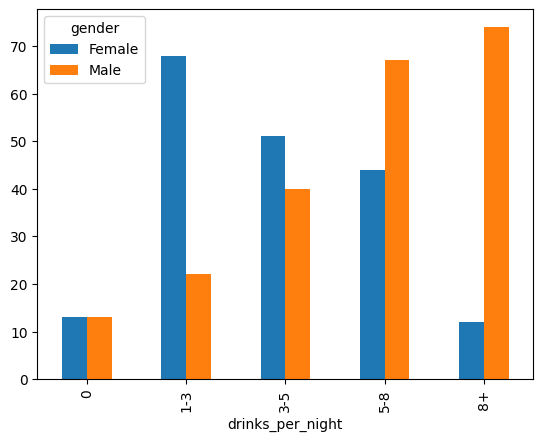

In [22]:
# Gender Specific Alcohal consumption

tabel = pd.crosstab(
    student_data.gender, 
    student_data.drinks_per_night
).T

tabel.plot(kind = "bar")

In [24]:
# Relation with parent and scored gained 

student_data.parent_relationship_strength.value_counts()

parent_relationship_strength
Very close    269
Close          97
Fair           35
Distant         2
Name: count, dtype: int64

In [25]:
groups = student_data.groupby(by = "parent_relationship_strength")

In [29]:
groups[["high_school_gpa", "uni_gpa_2023"]].aggregate(("min", "max", "median", "mean"))

high_school_gpa                           \
                                         min    max median       mean   
parent_relationship_strength                                            
Close                                   60.0  98.33   78.0  77.690000   
Distant                                 85.0  98.00   91.5  91.500000   
Fair                                    55.0  95.50   79.0  78.357143   
Very close                              34.0  99.00   78.0  77.960114   

                             uni_gpa_2023                           
                                      min    max median       mean  
parent_relationship_strength                                        
Close                                50.0  95.22   63.0  65.220769  
Distant                              88.0  89.00   88.5  88.500000  
Fair                                 50.0  85.00   66.0  66.258065  
Very close                           30.0  92.00   65.0  66.527356

In [ ]:
# Relation with HS and uni grade
